# Project | Recommendation System

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt   
import pandas
#from sklearn.cross_validation import train_test_split
import numpy as np
import time
from sklearn.externals import joblib
import Recommenders as Recommenders
import Evaluation as Evaluation

import pandas as pd

### Step 1 - 

In [3]:
colnames= ['userId', 'productId', 'ratings', 'timestamp']

In [7]:
df = pd.read_csv("ratings_Electronics.csv", header=None, names= colnames)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 4 columns):
userId       object
productId    object
ratings      float64
timestamp    int64
dtypes: float64(1), int64(1), object(2)
memory usage: 238.8+ MB


In [9]:
df.head()

,userId,productId,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [10]:
df.describe(include='all')

,userId,productId,ratings,timestamp
count,7824482,7824482,7.824482e+06,7.824482e+06
unique,4201696,476002,NaN,NaN
top,A5JLAU2ARJ0BO,B0074BW614,NaN,NaN
freq,520,18244,NaN,NaN
mean,NaN,NaN,4.012337e+00,1.338178e+09
std,NaN,NaN,1.380910e+00,6.900426e+07
min,NaN,NaN,1.000000e+00,9.127296e+08
25%,NaN,NaN,3.000000e+00,1.315354e+09
50%,NaN,NaN,5.000000e+00,1.361059e+09
75%,NaN,NaN,5.000000e+00,1.386115e+09


In [11]:
df[df['userId']=='A5JLAU2ARJ0BO'].head()

,userId,productId,ratings,timestamp
2162,A5JLAU2ARJ0BO,1400532655,1.0,1291334400
32736,A5JLAU2ARJ0BO,B00003006R,5.0,1052092800
35087,A5JLAU2ARJ0BO,B00003G1RG,3.0,1104796800
38345,A5JLAU2ARJ0BO,B00004S9AK,5.0,956880000
40411,A5JLAU2ARJ0BO,B00004SB92,4.0,1034726400


In [12]:
df['userId'].value_counts()

A5JLAU2ARJ0BO     520
ADLVFFE4VBT8      501
A3OXHLG6DIBRW8    498
A6FIAB28IS79      431
A680RUE1FDO8B     406
A1ODOGXEYECQQ8    380
A36K2N527TXXJN    314
A2AY4YUOX2N1BQ    311
AWPODHOB4GFWL     308
A25C2M3QF9G7OQ    296
ARBKYIVNYWK3C     296
A22CW0ZHY3NJH8    292
A3EXWV8FNSSFL6    282
A38RMU1Y5TDP9     282
A3LGT6UZL99IW1    279
A2NOW4U7W3F7RI    277
A23GFTVIETX7DS    270
A3PD8JD9L4WEII    266
A17BUUBOU0598B    261
A3AYSYSLHU26U9    257
A2XRMQA6PJ5ZJ8    253
A231WM2Z2JL0U3    252
A12DQZKRKTNF5E    252
A1UQBFCERIP7VJ    247
AGVWTYW0ULXHT     244
A203OCQQ12MAVT    240
AEJAGHLC675A7     239
A2NYK9KWFMJV4Y    238
A3A4ZAIBQWKOZS    236
A2UOHALGF2X77Q    227
                 ... 
A1NJD6SUKYRN8K      1
A3VAR48VA32WOG      1
AVIGYT0TXAE0D       1
A1MR0G2H9GDIKY      1
A11VBBY9GUR9TL      1
A1Z13AQU39YT0G      1
A9ITRVN0O1B1N       1
A3B09KJPHVFACV      1
A26FDBNPNTJ3VD      1
A2GDWUFFTJMFYP      1
A37WV9R6NBIU12      1
A1T7O8WQ2M3RN5      1
A2G6CZEKO2L9CU      1
AF41ELZ2DWMV6       1
A34YGD56IS

In [13]:
df_counts=pd.DataFrame(df['userId'].value_counts())
df_counts.head()


,userId
A5JLAU2ARJ0BO,520
ADLVFFE4VBT8,501
A3OXHLG6DIBRW8,498
A6FIAB28IS79,431
A680RUE1FDO8B,406


In [14]:
df_counts.shape

(4201696, 1)

In [15]:
df_counts['userId1']=df_counts.index

In [16]:
df_counts= df_counts[df_counts['userId']>=50]
df_counts.head()
df_counts.shape

(1540, 2)

In [17]:
df_counts.tail()

,userId,userId1
A27H61OHW44XA7,50,A27H61OHW44XA7
A3HH340REI4J47,50,A3HH340REI4J47
A1USYP4AXF5I1D,50,A1USYP4AXF5I1D
A2TVJ0YDW3QO63,50,A2TVJ0YDW3QO63
AXU8RH1DEV21H,50,AXU8RH1DEV21H


In [18]:
df_new=df[df['userId'].isin(df_counts['userId1'])]

In [19]:
df_new.head()
df_new.shape

(125871, 4)

In [20]:
df_new['ratings'].value_counts()

5.0    71034
4.0    32295
3.0    12060
2.0     5367
1.0     5115
Name: ratings, dtype: int64

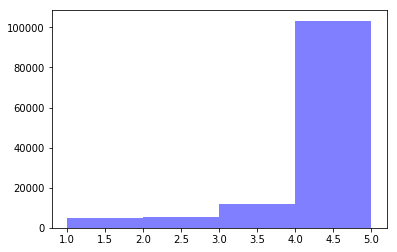

In [23]:
plt.hist(df_new['ratings'], 4, facecolor='blue', alpha=0.5)
plt.show()

### Observations and Findings:
1. Data had 4 million+ users making upto 7.8 Million+ product reviews
2. Only 1540 users have reviewed for more than 50 products
3. These 1540 users gave a total of 125K reviews
4. Most of the 56% of the reviews 5 star ratings and 26% are 4 star

In [24]:
71034/125871

0.5643396811020807

In [25]:
32295/125871

0.2565722048764211

In [79]:
df_new_grouped = df_new.groupby(['productId']).agg({'ratings': 'count'}).reset_index()
df_new_grouped

,productId,ratings
0,0594451647,1
1,0594481813,1
2,0970407998,2
3,0972683275,4
4,1400501466,6
5,1400501520,1
6,1400501776,2
7,1400532620,2
8,1400532655,6
9,140053271X,2


In [80]:

df_new_grouped['ratings'].sum()

125871

In [81]:
df_new_grouped.shape

(48190, 2)

In [84]:
grouped_sum = df_new_grouped['ratings'].sum()
df_new_grouped['percentage']  = df_new_grouped['ratings'].div(grouped_sum)*100
df_new_grouped.sort_values(['ratings', 'productId'], ascending = [0,1])

,productId,ratings,percentage
39003,B0088CJT4U,206,0.163660
24827,B003ES5ZUU,184,0.146181
11078,B000N99BBC,167,0.132676
38250,B007WTAJTO,164,0.130292
38615,B00829TIEK,149,0.118375
38611,B00829THK0,137,0.108842
39338,B008DWCRQW,137,0.108842
21982,B002R5AM7C,128,0.101691
28761,B004CLYEDC,118,0.093747
22210,B002SZEOLG,113,0.089774


In [85]:
df_new_grouped.head()

,productId,ratings,percentage
0,0594451647,1,0.000794
1,0594481813,1,0.000794
2,0970407998,2,0.001589
3,0972683275,4,0.003178
4,1400501466,6,0.004767


## Popularity model

In [88]:
df_new_u = df_new['productId'].value_counts()

In [87]:
from sklearn.model_selection import train_test_split

In [96]:
train_data, test_data = train_test_split(df_new[['userId','productId','ratings']], test_size = 0.30, random_state=7)

In [97]:
train_data.head()

,userId,productId,ratings
1808949,A1RJKTYC03L0JY,B001940MFO,5.0
5681482,A3EZEP0FX5BC1P,B0079TOI8K,4.0
1344931,ASFP250F22MDZ,B000S5KMSW,5.0
5727811,A1XXMNLOLKNO0I,B007F9XHBI,5.0
5957853,AWNBZSEZ9P8BE,B007X3VEX4,4.0


In [99]:
pm = Recommenders.popularity_recommender_py()
pm.create(train_data, 'userId', 'productId')

KeyError: 'score'

## Collaborative Filtering model

In [106]:
review_data=df_new

In [107]:
## Step 2: Find common movies between critics
def get_common_movies(criticA,criticB):
    return [movie for movie in review_data[criticA] if movie in review_data[criticB]]

In [108]:
71034/125871

0.5643396811020807

In [109]:
## Step 2: Find common movies between critics
def get_common_movies(criticA,criticB):
    return [movie for movie in df_new[criticA] if movie in review_data[criticB]]

In [115]:
## Step 3: Get Reviews of common movies
def get_reviews(criticA,criticB):
    common_movies = get_common_movies(criticA,criticB)
    return [(review_data[criticA][movie], review_data[criticB][movie]) for movie in common_movies]

In [110]:
def euclidean_distance(points):
    squared_diffs = [(point[0] - point[1]) ** 2 for point in points]
    summed_squared_diffs = sum(squared_diffs)
    distance = math.sqrt(summed_squared_diffs)
    return distance

In [111]:
### Step 4: Compare similarity between reviews using Euclidean distance
def similarity(reviews):
    return 1/ (1 + euclidean_distance(reviews))

In [112]:
## Step 5: Compare similarity between critics
def get_critic_similarity(criticA, criticB):
    reviews = get_reviews(criticA,criticB)
   # print(reviews)
    return similarity(reviews)

In [116]:
##Step 6: Compile similarity scores of all critics except himself/herself
def recommend_movies(critic):
    similarity_scores = [(get_critic_similarity(critic, other), other) for other in review_data if other != critic]

    similarity_scores.sort()
    similarity_scores.reverse() ## sort the similarity score between the critics in reverse order
    print(similarity_scores) ##similarity score: (1.0, 'R4') : similarity score, critic name
    print("\n")
   

    recommendations = {}
    
    ##simularity=similarity score; other=other critic, say R4,R5. We will loop through all critics
    for simularity, other in similarity_scores: 
        reviewed = review_data[other] ## get all the movies reviewed by other critic
        #print(other,reviewed)
        
        for movie in reviewed:## browse through each movie
            if movie not in review_data[critic]: ## the critic should not watch that movie
                weight = simularity * reviewed[movie] #weight=similarity score
                #print(movie,weight)

                if movie in recommendations:
                    sim, weights = recommendations[movie]
                    recommendations[movie] = (sim + simularity, weights + [weight])
                    #print(recommendations[movie])
        
                else:
                    recommendations[movie] = (simularity, [weight])
                    print(recommendations[movie])

    for recommendation in recommendations:
        simularity, movie = recommendations[recommendation]
        recommendations[recommendation] = sum(movie) / simularity

    sorted_recommendations = sorted(recommendations.items(), key=operator.itemgetter(1), reverse=True)

    return sorted_recommendations

In [117]:
recommend_movies('A1RJKTYC03L0JY')

KeyError: 'A1RJKTYC03L0JY'